In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

In [2]:
#Run this to use Latex-like font
plt.rcParams.update({
    "mathtext.fontset": "cm", # 'cm' for Computer Modern, 'stix' for Times-like
    "font.family": "serif",
    "axes.formatter.use_mathtext": True,
    "font.size":14,
    'axes.prop_cycle':plt.cycler(color=plt.cm.Set1.colors)
})

In [3]:
def Normal(x):
    return np.exp(-x**2/2)/np.sqrt(2*np.pi)

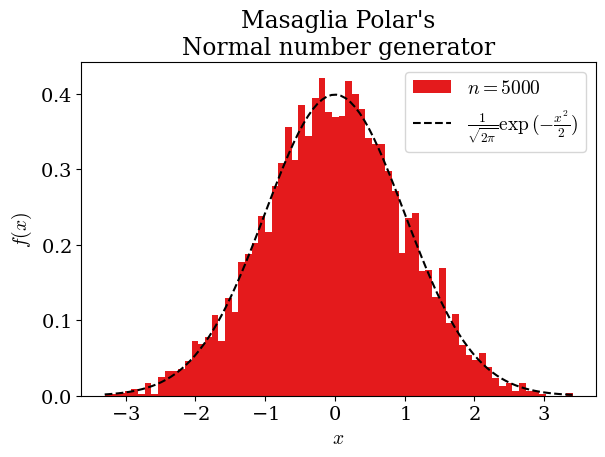

In [4]:
#k = int(1+np.log2(5000))
k = int(np.sqrt(5000))
data = np.loadtxt('./output/normal_5000.dat')
X = np.linspace(min(data), max(data), 100)
plt.hist(data, density=True,bins=k,label=r'$n=5000$')
plt.plot(X,Normal(X),color='black', ls='dashed', label=r'$\frac{1}{\sqrt{2\pi}}\exp{(-\frac{x^2}{2})}$')

plt.title("Masaglia Polar's\nNormal number generator")
plt.xlabel(r'$x$')
plt.ylabel(r'$f(x)$')
plt.legend()
plt.tight_layout()
plt.savefig("./image/normal.png")

In [5]:
def MSD(t,Temp):
    return 6*Temp*(t+np.exp(-t)-1)

In [28]:
#get array of strin
output = Path('./output/result')
files = [f.name for f in output.iterdir() if f.is_file()]
print(files)

def graph(file_name):
    temp = file_name[5:]
    file_path = "./output/result/"+file_name
    t, msd_array, correla_array = np.loadtxt(file_path, comments = "#", unpack = True)
    return temp, t, msd_array, correla_array

['temp_0.0001', 'temp_0.0010', 'temp_0.0100', 'temp_0.1000', 'temp_1.0000']


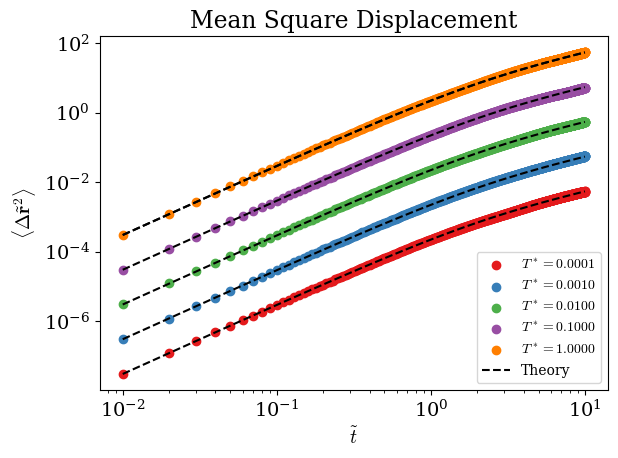

In [58]:

fig, ax  = plt.subplots()
ax.set_title("Mean Square Displacement")
for i in files:
    temp, t, msd,corre = graph(i)
    T = float(temp)
    xtemp = np.logspace(-2,1,base=10)
    ax.scatter(t,msd, label= rf"$T^*={T:.4f}$")
    ax.plot(xtemp, MSD(xtemp, T), color='black', ls = 'dashed')

ax.set_xlabel(r"$\tilde{t}$")
ax.set_ylabel(r"$\langle\Delta\tilde{\mathbf{r}}^2\rangle$")
ax.plot(xtemp, MSD(xtemp, T), color='black', ls = 'dashed', label = rf"Theory")
ax.legend(loc='lower right', fontsize=10)
ax.set_yscale('log')
ax.set_xscale('log')
fig.tight_layout()
fig.savefig('./image/MSD.png')

In [43]:
def Corre(t,temp):
    return 3*temp*np.exp(-t)

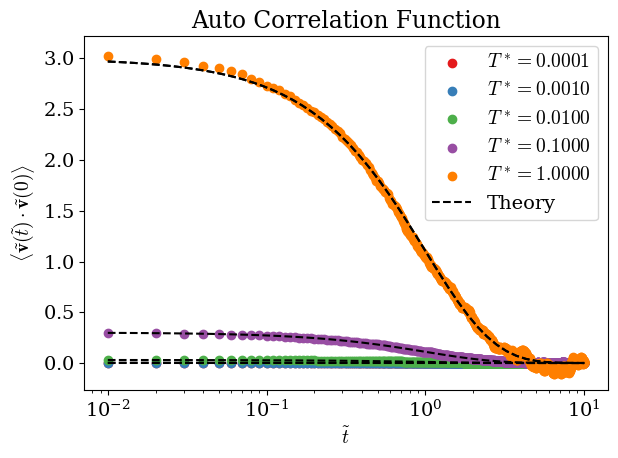

In [59]:
fig, ax  = plt.subplots()
ax.set_title("Auto Correlation Function")
for i in files:
    temp, t, msd,corre = graph(i)
    T = float(temp)
    xtemp = np.logspace(-2,1,base=10)
    ax.scatter(t,corre, label= rf"$T^*={T:.4f}$")
    ax.plot(xtemp, Corre(xtemp, T), color='black', ls = 'dashed')


ax.plot(xtemp, Corre(xtemp, T), color='black', ls = 'dashed', label = rf"Theory")
ax.set_xlabel(r"$\tilde{t}$")
ax.set_ylabel(r"$\langle\tilde{\mathbf{v}}(\tilde{t})\cdot\tilde{\mathbf{v}}(0)\rangle$")
ax.legend( loc='upper right')
#ax.set_yscale('log')
ax.set_xscale('log')
fig.tight_layout()
fig.savefig('./image/Correlation.png')

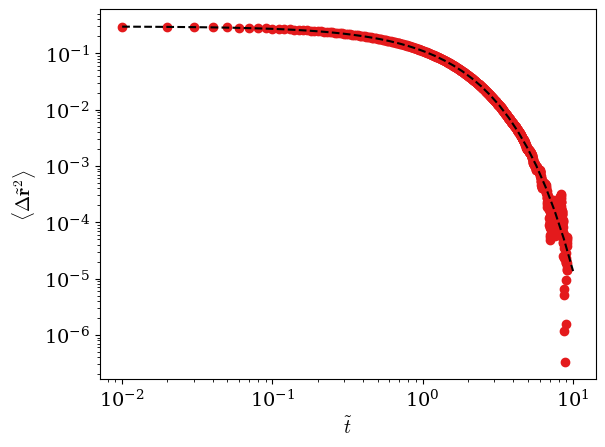

In [40]:
fig, ax  = plt.subplots()

xtemp = np.logspace(-2,1,base=10)
ax.scatter(t,C)
Temp = 0.1
ax.plot(xtemp, Corre(xtemp, Temp), color='black', ls = 'dashed')

ax.set_xlabel(r"$\tilde{t}$")
ax.set_ylabel(r"$\langle\Delta\tilde{\mathbf{r}}^2\rangle$")
ax.set_yscale('log')
ax.set_xscale('log')